In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("data/processed/preprocessed_dataset.csv")

df.head()

,Vehicle_ID,Make_and_Model,Vehicle_Type,Year_of_Manufacture,Route_Info,Weather_Conditions,Road_Conditions,Communication_Interface,Telematics_Gateway,Edge_Device_Class,Usage_Hours,Load_Capacity,Actual_Load,Engine_Temperature,Tire_Pressure,Fuel_Consumption,Battery_Status,Vibration_Levels,Oil_Quality,Failure_History,Anomalies_Detected,Diagnostic_Trouble_Code_Count,CAN_Message_Rate_Hz,Sensor_Packet_Loss_Rate,Maintenance_Cost,Historical_Maintenance_Cost,Downtime_Maintenance,Impact_on_Efficiency,Days_Since_Last_Maintenance,Last_Maintenance_Date,Maintenance_Type,Brake_Condition,Maintenance_Severity,Maintenance_Severity_ID,Maintenance_Required,PCR,UIR,TPI,MBF,ADS,OHI,CMES,UER,Predictive_Score,Pre_Event_Record,Data_Split,FL_Client_ID,Partition_Type,Local_Epochs_Per_Round,Communication_Rounds
0,1,1,4,2016,1,4,4,1,2,2,13475.0478,15000,8251.3552,89.9289,40.0072,6.6281,89.5450,0.4901,82.2913,0,0,0,43.3507,0.0018,208.8794,208.8794,0.9331,0.0816,32,2024-11-30,9,0,2,0,0,0.5501,0.6738,2.2478,208.8794,0.0,1.5736,1.4739,64.2038,0.1582,1,1,1,0,2,200
1,2,0,2,2017,1,5,3,2,0,3,12105.1067,15000,7613.2738,87.2995,36.7408,7.5610,100.0000,0.8491,89.2770,0,1,0,38.3010,0.0000,420.8862,420.8862,1.6612,0.1355,49,2024-11-13,6,0,2,0,0,0.5076,0.6725,2.3761,420.8862,1.0,1.4027,2.6860,28.6928,0.1757,1,0,1,0,2,200
2,3,3,3,2011,1,4,0,2,0,1,20603.3452,10000,5659.3477,84.5161,37.9191,8.4989,80.2054,1.2097,91.0640,1,0,0,27.6667,0.0114,267.4467,267.4467,0.4846,0.1114,56,2024-11-06,7,1,2,0,0,0.5659,0.6868,2.2289,334.3084,0.5,2.2707,1.4311,76.7502,0.2047,1,1,2,0,2,200
3,4,4,0,2020,0,5,1,0,2,0,7629.6116,1500,794.9140,97.0480,38.1387,8.0534,90.2121,1.7252,88.3515,0,0,0,38.1587,0.0073,169.4832,169.4832,0.7676,0.0668,92,2024-10-01,7,1,2,0,0,0.5299,0.6358,2.5446,169.4832,0.0,1.0520,1.3057,44.7529,0.1689,1,1,3,0,2,200
4,5,4,1,2024,1,4,2,2,2,3,1368.6403,5000,1953.2295,91.1374,36.7930,7.8788,81.0800,1.1453,97.8955,1,0,1,48.1264,0.0099,344.9016,344.9016,2.5830,0.0808,35,2024-11-27,9,1,2,0,0,0.3906,0.3422,2.4770,431.1270,0.7,0.2724,3.2195,3.9567,0.1895,1,1,4,0,2,200


In [3]:
target = "Maintenance_Required"

In [4]:
corr = df.corr(numeric_only=True)

target_corr = (
    corr[target]
    .sort_values(ascending=False)
)

target_corr

Maintenance_Required             1.000000e+00
Maintenance_Severity_ID          9.211324e-01
Predictive_Score                 8.647857e-01
Impact_on_Efficiency             8.077735e-01
Fuel_Consumption                 8.026815e-01
Days_Since_Last_Maintenance      7.984457e-01
CMES                             7.880950e-01
TPI                              7.878946e-01
Vibration_Levels                 7.778836e-01
Engine_Temperature               7.593894e-01
Downtime_Maintenance             7.496732e-01
ADS                              7.365913e-01
Maintenance_Cost                 7.277572e-01
Historical_Maintenance_Cost      7.277572e-01
CAN_Message_Rate_Hz              7.227375e-01
Sensor_Packet_Loss_Rate          7.097850e-01
Anomalies_Detected               6.721545e-01
PCR                              6.684144e-01
MBF                              6.614837e-01
Diagnostic_Trouble_Code_Count    6.529756e-01
Failure_History                  6.141804e-01
OHI                              3

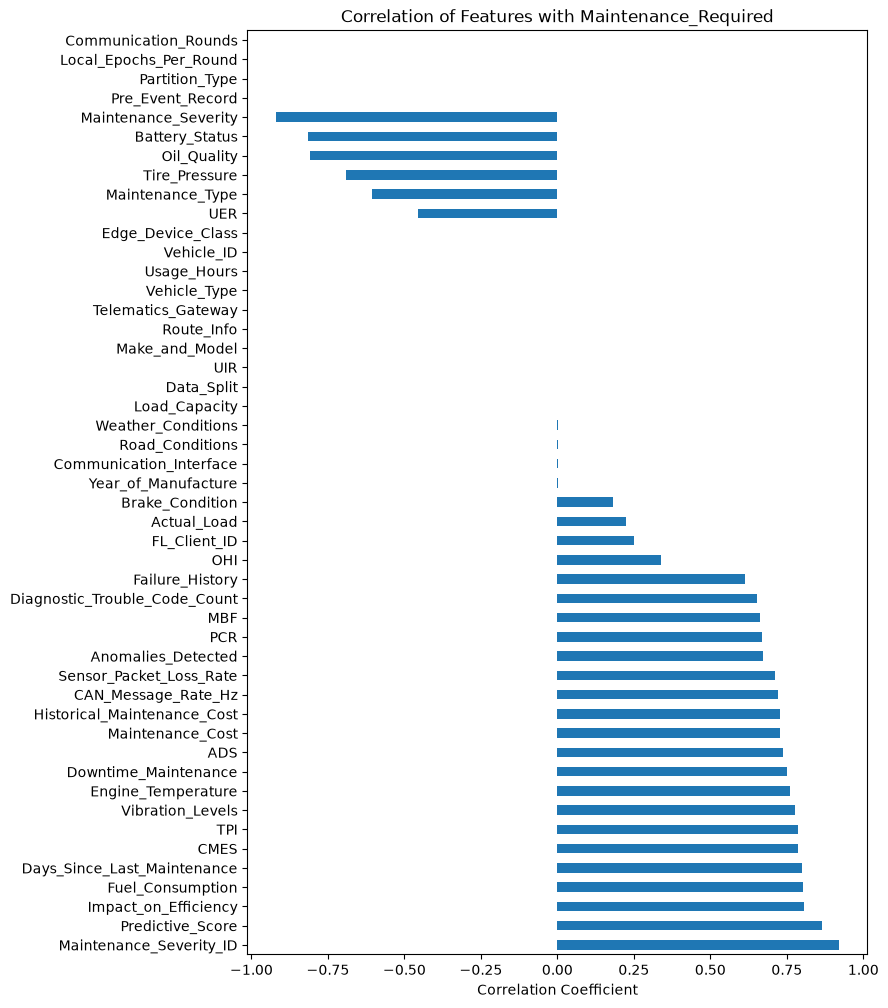

In [5]:
plt.figure(figsize=(8, 12))

target_corr.drop(target).plot(kind="barh")

plt.title("Correlation of Features with Maintenance_Required")
plt.xlabel("Correlation Coefficient")

plt.show()

In [6]:
high_corr = target_corr[
    abs(target_corr) > 0.80
]

high_corr

Maintenance_Required       1.000000
Maintenance_Severity_ID    0.921132
Predictive_Score           0.864786
Impact_on_Efficiency       0.807774
Fuel_Consumption           0.802682
Oil_Quality               -0.807180
Battery_Status            -0.814927
Maintenance_Severity      -0.921132
Name: Maintenance_Required, dtype: float64

In [7]:
suspected_leakage = pd.DataFrame({
    "Feature": [
        "Predictive_Score",
        "PCR",
        "UIR",
        "TPI",
        "MBF",
        "ADS",
        "OHI",
        "CMES",
        "UER",
        "Maintenance_Cost",
        "Downtime_Maintenance",
        "Maintenance_Type",
        "Maintenance_Severity",
        "Maintenance_Severity_ID"
    ],
    "Reason": [
        "Composite prediction score",
        "Engineered metric",
        "Engineered metric",
        "Engineered metric",
        "Engineered metric",
        "Engineered metric",
        "Overall health index",
        "Composite maintenance score",
        "Engineered metric",
        "Known after maintenance",
        "Known after maintenance",
        "Assigned after maintenance",
        "Represents maintenance outcome",
        "Encoded maintenance severity"
    ]
})

suspected_leakage

,Feature,Reason
0,Predictive_Score,Composite prediction score
1,PCR,Engineered metric
2,UIR,Engineered metric
3,TPI,Engineered metric
4,MBF,Engineered metric
5,ADS,Engineered metric
6,OHI,Overall health index
7,CMES,Composite maintenance score
8,UER,Engineered metric
9,Maintenance_Cost,Known after maintenance


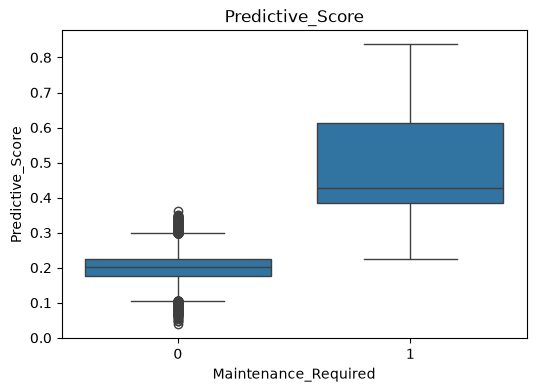

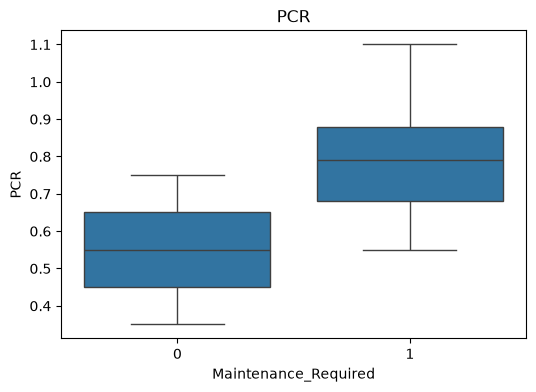

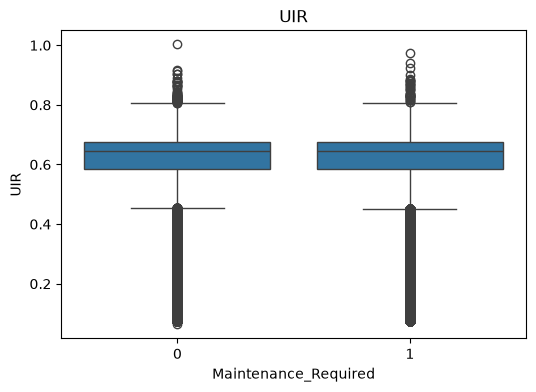

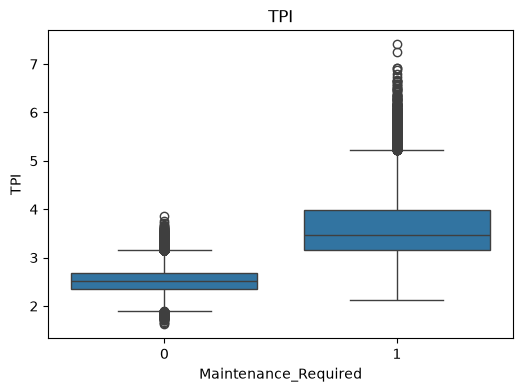

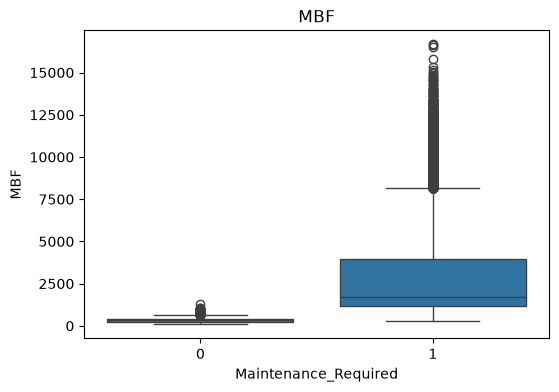

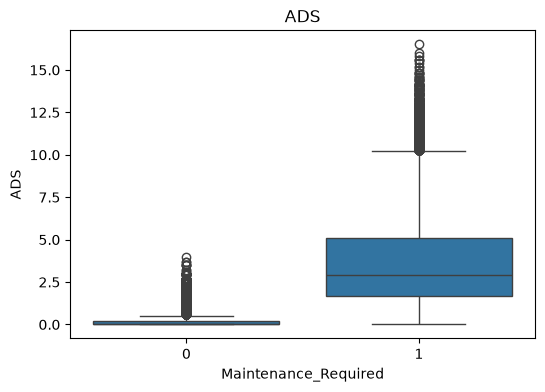

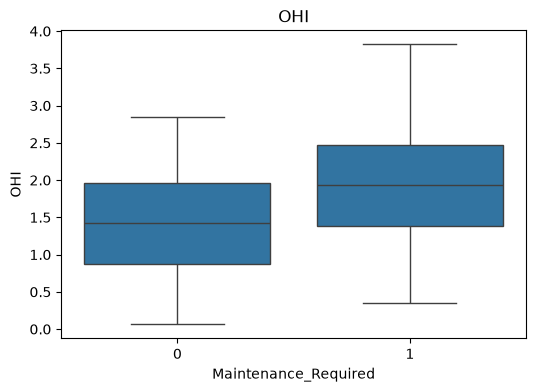

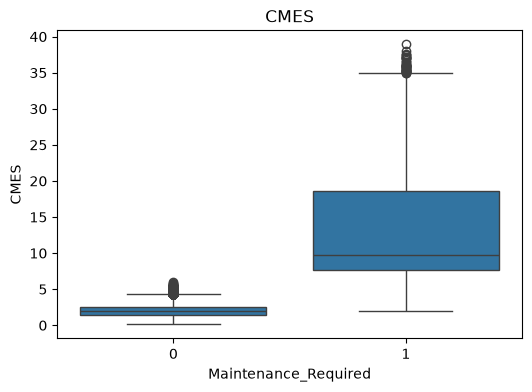

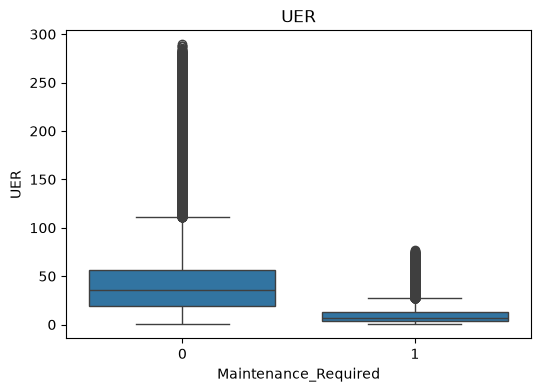

In [8]:
suspect_features = [
    "Predictive_Score",
    "PCR",
    "UIR",
    "TPI",
    "MBF",
    "ADS",
    "OHI",
    "CMES",
    "UER"
]

for feature in suspect_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x="Maintenance_Required",
        y=feature,
        data=df
    )

    plt.title(feature)

    plt.show()

In [9]:
leakage_features = [
    "Predictive_Score",
    "PCR",
    "UIR",
    "TPI",
    "MBF",
    "ADS",
    "OHI",
    "CMES",
    "UER",
    "Maintenance_Cost",
    "Downtime_Maintenance",
    "Maintenance_Type",
    "Maintenance_Severity",
    "Maintenance_Severity_ID"
]

print("Number of suspected leakage features:", len(leakage_features))

Number of suspected leakage features: 14


In [10]:
df_clean = df.drop(columns=leakage_features)

df_clean.head()

,Vehicle_ID,Make_and_Model,Vehicle_Type,Year_of_Manufacture,Route_Info,Weather_Conditions,Road_Conditions,Communication_Interface,Telematics_Gateway,Edge_Device_Class,Usage_Hours,Load_Capacity,Actual_Load,Engine_Temperature,Tire_Pressure,Fuel_Consumption,Battery_Status,Vibration_Levels,Oil_Quality,Failure_History,Anomalies_Detected,Diagnostic_Trouble_Code_Count,CAN_Message_Rate_Hz,Sensor_Packet_Loss_Rate,Historical_Maintenance_Cost,Impact_on_Efficiency,Days_Since_Last_Maintenance,Last_Maintenance_Date,Brake_Condition,Maintenance_Required,Pre_Event_Record,Data_Split,FL_Client_ID,Partition_Type,Local_Epochs_Per_Round,Communication_Rounds
0,1,1,4,2016,1,4,4,1,2,2,13475.0478,15000,8251.3552,89.9289,40.0072,6.6281,89.5450,0.4901,82.2913,0,0,0,43.3507,0.0018,208.8794,0.0816,32,2024-11-30,0,0,1,1,1,0,2,200
1,2,0,2,2017,1,5,3,2,0,3,12105.1067,15000,7613.2738,87.2995,36.7408,7.5610,100.0000,0.8491,89.2770,0,1,0,38.3010,0.0000,420.8862,0.1355,49,2024-11-13,0,0,1,0,1,0,2,200
2,3,3,3,2011,1,4,0,2,0,1,20603.3452,10000,5659.3477,84.5161,37.9191,8.4989,80.2054,1.2097,91.0640,1,0,0,27.6667,0.0114,267.4467,0.1114,56,2024-11-06,1,0,1,1,2,0,2,200
3,4,4,0,2020,0,5,1,0,2,0,7629.6116,1500,794.9140,97.0480,38.1387,8.0534,90.2121,1.7252,88.3515,0,0,0,38.1587,0.0073,169.4832,0.0668,92,2024-10-01,1,0,1,1,3,0,2,200
4,5,4,1,2024,1,4,2,2,2,3,1368.6403,5000,1953.2295,91.1374,36.7930,7.8788,81.0800,1.1453,97.8955,1,0,1,48.1264,0.0099,344.9016,0.0808,35,2024-11-27,1,0,1,1,4,0,2,200


In [11]:
print("Original Shape :", df.shape)
print("After Removal :", df_clean.shape)

Original Shape : (250000, 50)
After Removal : (250000, 36)


In [12]:
df_clean.to_csv(
    "data/processed/leakage_free_dataset.csv",
    index=False
)